In [75]:
!pip install ydata-profiling

In [76]:
import pandas as pd
from ydata_profiling import ProfileReport

# Load dataset
df = pd.read_csv('/content/my2015-2024-fuel-consumption-ratings.csv')

# Create profiling report
profile = ProfileReport(df, title="Fuel Consumption Profiling Report")

# Display report
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:00<00:00, 27.12it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

**Manual EDA**

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
df = pd.read_csv('/content/my2015-2024-fuel-consumption-ratings.csv')

**DATASET OVERVIEW**

In [79]:
df.head()

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
0,2015,Acura,ILX,Compact,2.0,4,AS5,Z,9.7,6.7,8.3,34,191,NaN,NaN
1,2015,Acura,ILX,Compact,2.4,4,M6,Z,10.8,7.4,9.3,30,214,NaN,NaN
2,2015,Acura,ILX Hybrid,Compact,1.5,4,AV7,Z,6.0,6.1,6.1,46,140,NaN,NaN
3,2015,Acura,MDX SH-AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.7,9.1,11.1,25,255,NaN,NaN
4,2015,Acura,RDX AWD,Sport utility vehicle: Small,3.5,6,AS6,Z,12.1,8.7,10.6,27,244,NaN,NaN


In [80]:
df.shape

(10060, 15)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10060 entries, 0 to 10059
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model year            10060 non-null  int64  
 1   Make                  10060 non-null  object 
 2   Model                 10060 non-null  object 
 3   Vehicle class         10060 non-null  object 
 4   Engine size (L)       10060 non-null  float64
 5   Cylinders             10060 non-null  int64  
 6   Transmission          10060 non-null  object 
 7   Fuel type             10060 non-null  object 
 8   City (L/100 km)       10060 non-null  float64
 9   Highway (L/100 km)    10060 non-null  float64
 10  Combined (L/100 km)   10060 non-null  float64
 11  Combined (mpg)        10060 non-null  int64  
 12  CO2 emissions (g/km)  10060 non-null  int64  
 13  CO2 rating            8932 non-null   float64
 14  Smog rating           7826 non-null   float64
dtypes: float64(6), int6

**DATA CLEANING**

In [82]:
#check missing values
df.isnull().sum()

,0
Model year,0
Make,0
Model,0
Vehicle class,0
Engine size (L),0
Cylinders,0
Transmission,0
Fuel type,0
City (L/100 km),0
Highway (L/100 km),0


In [83]:
# Check summary statistics for CO2 rating and Smog rating
df[['CO2 rating', 'Smog rating']].describe()

,CO2 rating,Smog rating
count,8932.000000,7826.000000
mean,4.617443,4.816509
std,1.574763,1.783793
min,1.000000,1.000000
25%,4.000000,3.000000
50%,5.000000,5.000000
75%,5.000000,6.000000
max,10.000000,8.000000


In [84]:
# Check median and mode values
print("CO2 rating median:", df['CO2 rating'].median())
print("CO2 rating mode:", df['CO2 rating'].mode()[0])

print("Smog rating median:", df['Smog rating'].median())
print("Smog rating mode:", df['Smog rating'].mode()[0])

CO2 rating median: 5.0
CO2 rating mode: 5.0
Smog rating median: 5.0
Smog rating mode: 5.0


In [85]:
# Impute missing values using median
df['CO2 rating'] = df['CO2 rating'].fillna(df['CO2 rating'].median())

df['Smog rating'] = df['Smog rating'].fillna(df['Smog rating'].median())

CO₂ Rating and Smog Rating contain missing values. These variables are ordinal rating variables, so median imputation is used instead of mean imputation to avoid creating unrealistic decimal rating values.

In [86]:
# check again missing values
df.isnull().sum()

,0
Model year,0
Make,0
Model,0
Vehicle class,0
Engine size (L),0
Cylinders,0
Transmission,0
Fuel type,0
City (L/100 km),0
Highway (L/100 km),0


In [87]:
# check duplicate values
df.duplicated().sum()

np.int64(0)

**A. Univariate Analysis**

**1.** **CO2 Emission distribution**

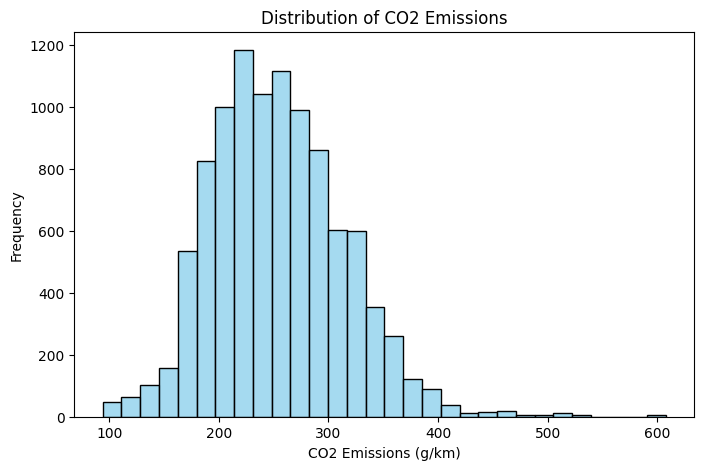

In [88]:
plt.figure(figsize=(8,5))
sns.histplot(df['CO2 emissions (g/km)'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of CO2 Emissions')
plt.xlabel('CO2 Emissions (g/km)')
plt.ylabel('Frequency')
plt.show()

This distribution shows that most vehicles fall within a moderate CO2 emissions range, while some vehicles produce significantly higher emissions levels.

**2**. **Fuel Consumption Distibution**

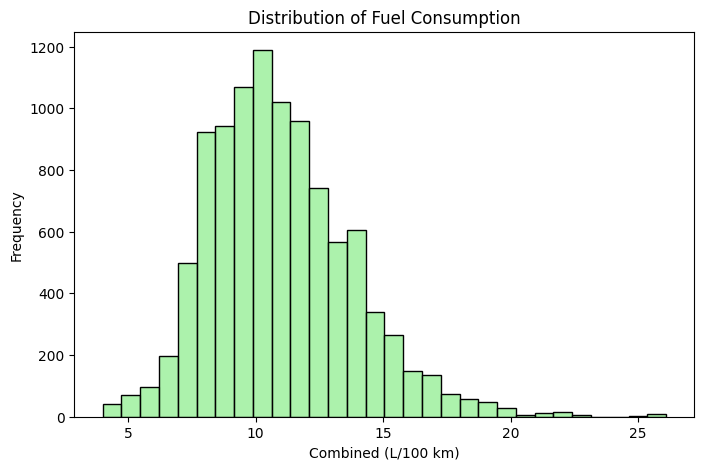

In [89]:
# Histogram of Distribution of Fuel Consumption
plt.figure(figsize=(8,5))

sns.histplot(
    df['Combined (L/100 km)'],
    bins=30,
    color='lightgreen',
    edgecolor='black'
)

plt.title('Distribution of Fuel Consumption')
plt.xlabel('Combined (L/100 km)')
plt.ylabel('Frequency')

plt.show()

Most vehicles have moderate fuel consumption levels and smaller number of vehicles show very high fuel consumption patterns.

**3. Fuel consumption Boxplot**

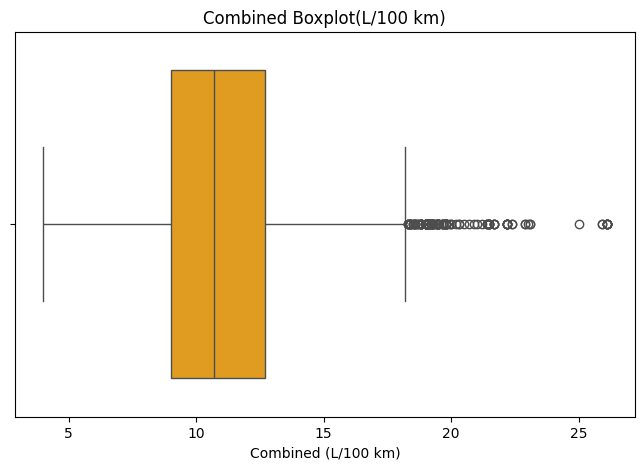

In [90]:
# Creating boxplot of Combined (L/100 km)
plt.figure(figsize=(8,5))
sns.boxplot(
    x=df['Combined (L/100 km)'],
    color='orange')
plt.title('Combined Boxplot(L/100 km)')
plt.show()

Boxplot identifies several high fuel-consumption outliers, indicating that some vehicle models consume substantially more fuel than the majority of vehicles in the datas

**4. Engine Size Distribution**

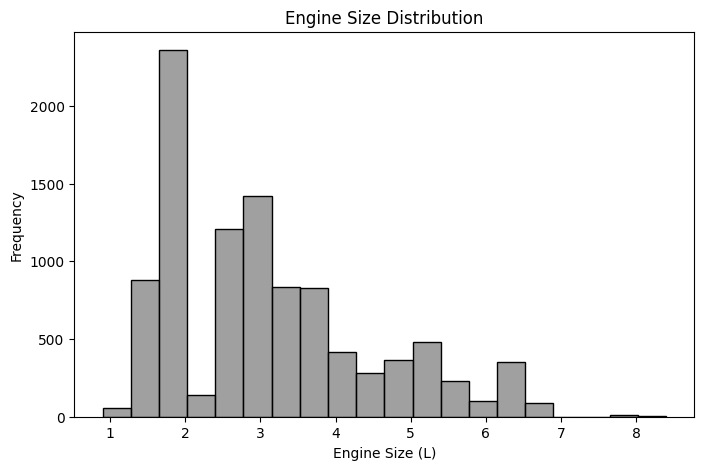

In [91]:
# Histogram of Engine Size Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['Engine size (L)'],
    bins=20,
    color='grey',
    edgecolor='black'
)

plt.title('Engine Size Distribution')
plt.xlabel('Engine Size (L)')
plt.ylabel('Frequency')

plt.show()

Analysis shows that smaller and medium engine sizes are more common in the dataset compared with larger engine vehicles.

**5. Vehicle class Distribution**

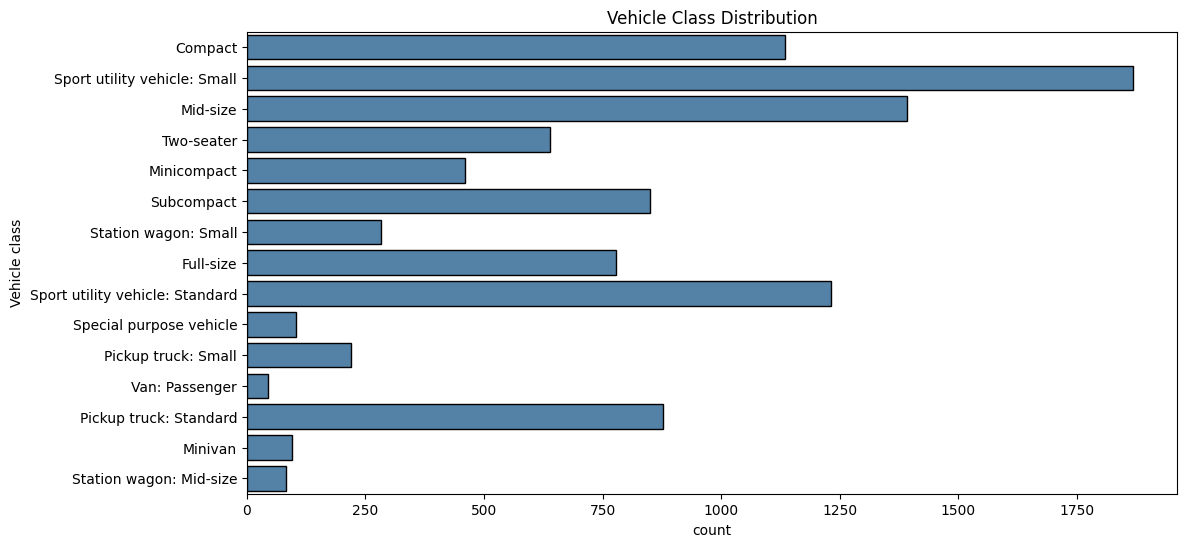

In [92]:
# Vehicle Class Distribution
plt.figure(figsize=(12,6))

sns.countplot(
    y='Vehicle class',
    data=df,
    color='steelblue',
    edgecolor='black'
)

plt.title('Vehicle Class Distribution')

plt.show()

Certain vehicle classes appear more frequently in the dataset, indicating higher representation of specific vehicle categories in the Canadian market.

**B. Bivariate Analysis**

**1. Engine Size vs CO2 Emission**

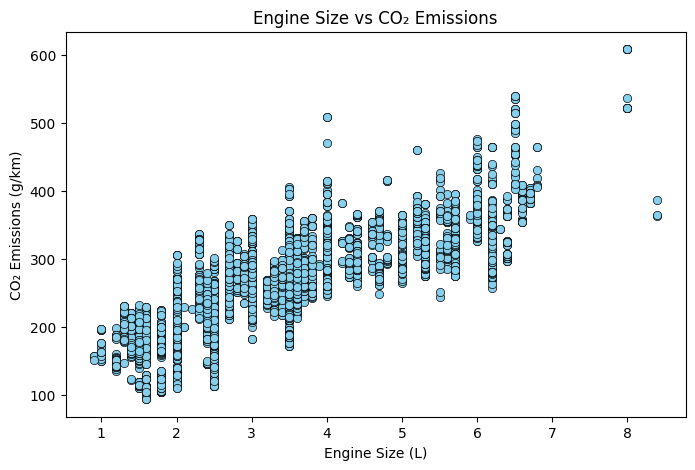

In [93]:
# Engine Size vs CO2 Emission
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Engine size (L)',
    y='CO2 emissions (g/km)',
    data=df,
    color='skyblue',
    edgecolor='black'
)

plt.title('Engine Size vs CO₂ Emissions')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO₂ Emissions (g/km)')

plt.show()

The scatterplot shows a positive relationship between engine size and CO₂ emissions, where larger engines are generally associated with higher emissions.

**2. Cylinder vs Fuel Consumption**

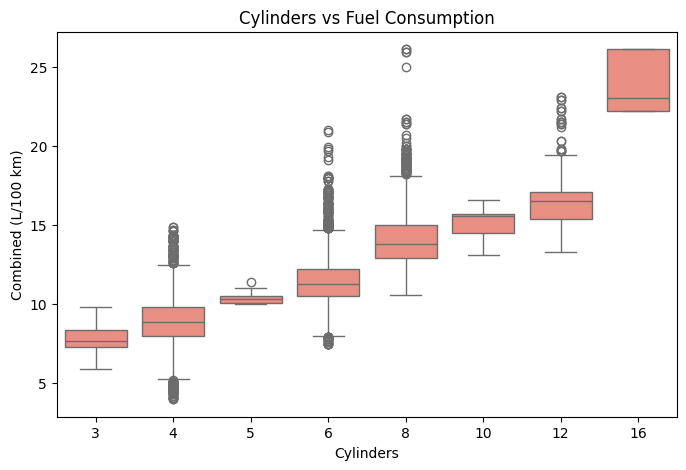

In [94]:
# Cylinder vs Fuel Consumption
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Cylinders',
    y='Combined (L/100 km)',
    data=df,
    color='salmon'
)

plt.title('Cylinders vs Fuel Consumption')
plt.xlabel('Cylinders')
plt.ylabel('Combined (L/100 km)')

plt.show()

Vehicles with a higher number of cylinders generally demonstrate increased fuel consumption compared with vehicles having fewer cylinders.

**3. Vehicle Class vs CO2 Emission**

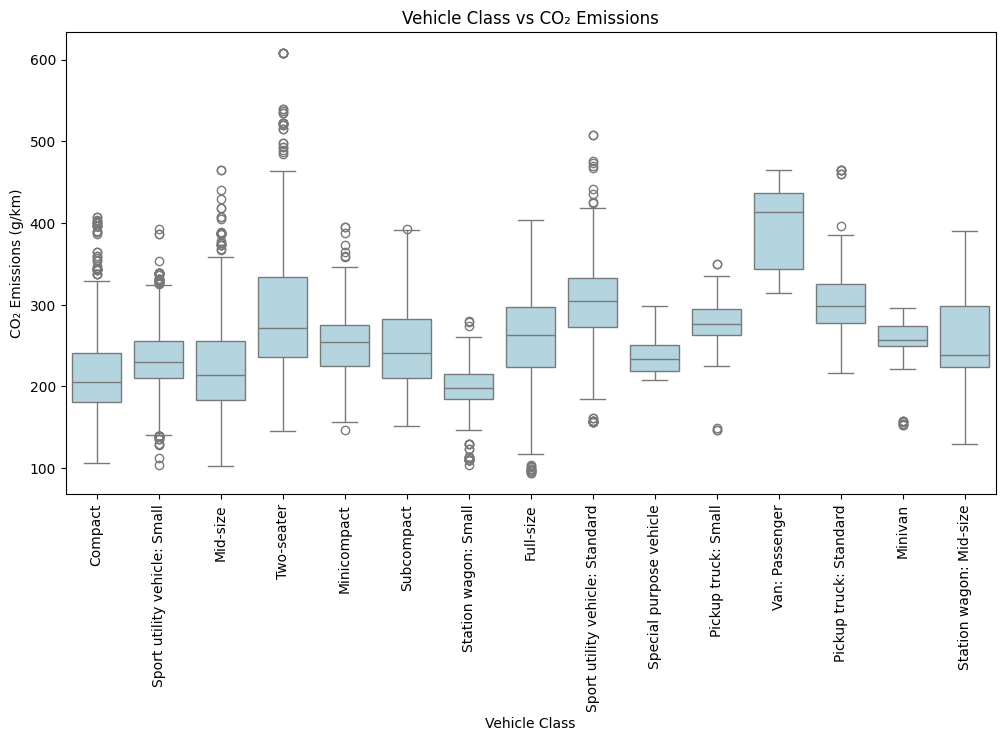

In [95]:
#  Vehicle Class vs CO2 Emission
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Vehicle class',
    y='CO2 emissions (g/km)',
    data=df,
    color='lightblue'
)

plt.xticks(rotation=90)

plt.title('Vehicle Class vs CO₂ Emissions')
plt.xlabel('Vehicle Class')
plt.ylabel('CO₂ Emissions (g/km)')

plt.show()

Larger vehicle categories such as SUVs and pickup trucks tend to produce higher CO₂ emissions compared with smaller vehicle classes.

**4. Fuel Type vs CO₂ Emissions**

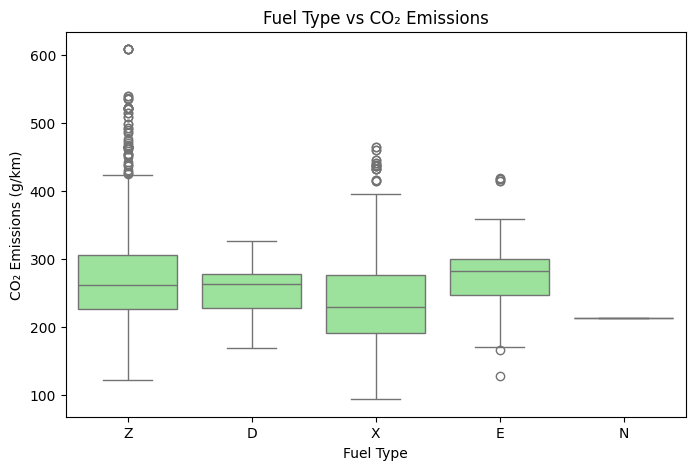

In [96]:
# Fuel Type vs CO₂ Emissions
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Fuel type',
    y='CO2 emissions (g/km)',
    data=df,
    color='lightgreen'
)

plt.title('Fuel Type vs CO₂ Emissions')
plt.xlabel('Fuel Type')
plt.ylabel('CO₂ Emissions (g/km)')

plt.show()

Fuel type appears to influence vehicle emissions, with some fuel systems showing lower average CO₂ emissions than others.

**5. CO2 Rating vs CO2 Emissions**

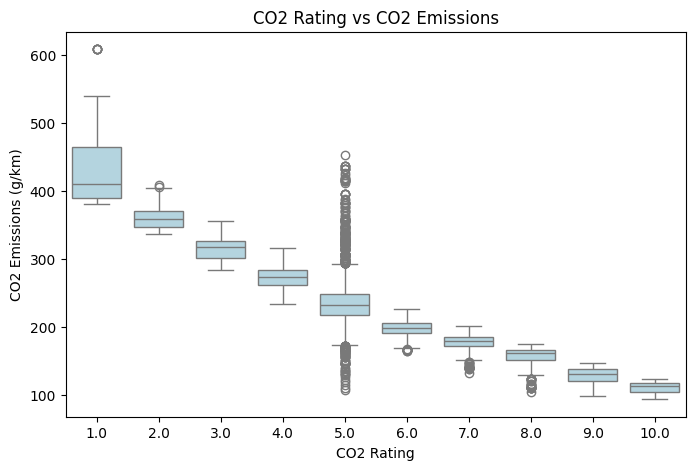

In [97]:
# CO2 Rating vs CO2 Emissions
plt.figure(figsize=(8,5))
sns.boxplot(
    x='CO2 rating',
    y='CO2 emissions (g/km)',
    data=df,
    color='lightblue'
)
plt.title('CO2 Rating vs CO2 Emissions')
plt.xlabel('CO2 Rating')
plt.ylabel('CO2 Emissions (g/km)')
plt.show()

**6. Smog Rating vs CO2 Emissions**

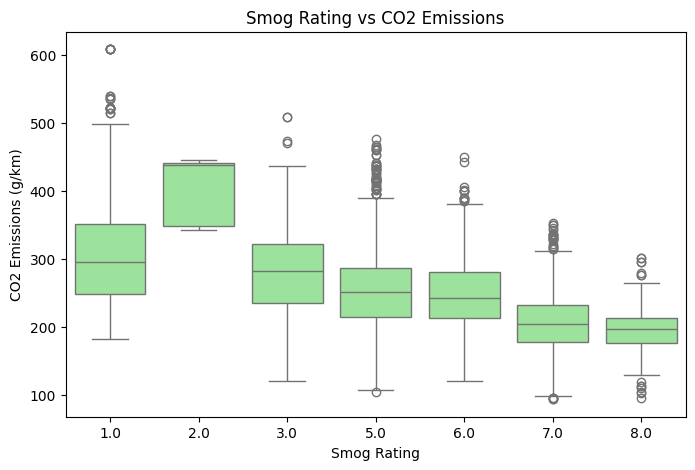

In [98]:
#  Smog Rating vs CO2 Emissions
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Smog rating',
    y='CO2 emissions (g/km)',
    data=df,
    color='lightgreen'
)
plt.title('Smog Rating vs CO2 Emissions')
plt.xlabel('Smog Rating')
plt.ylabel('CO2 Emissions (g/km)')
plt.show()

**5. Correlation Matrix**

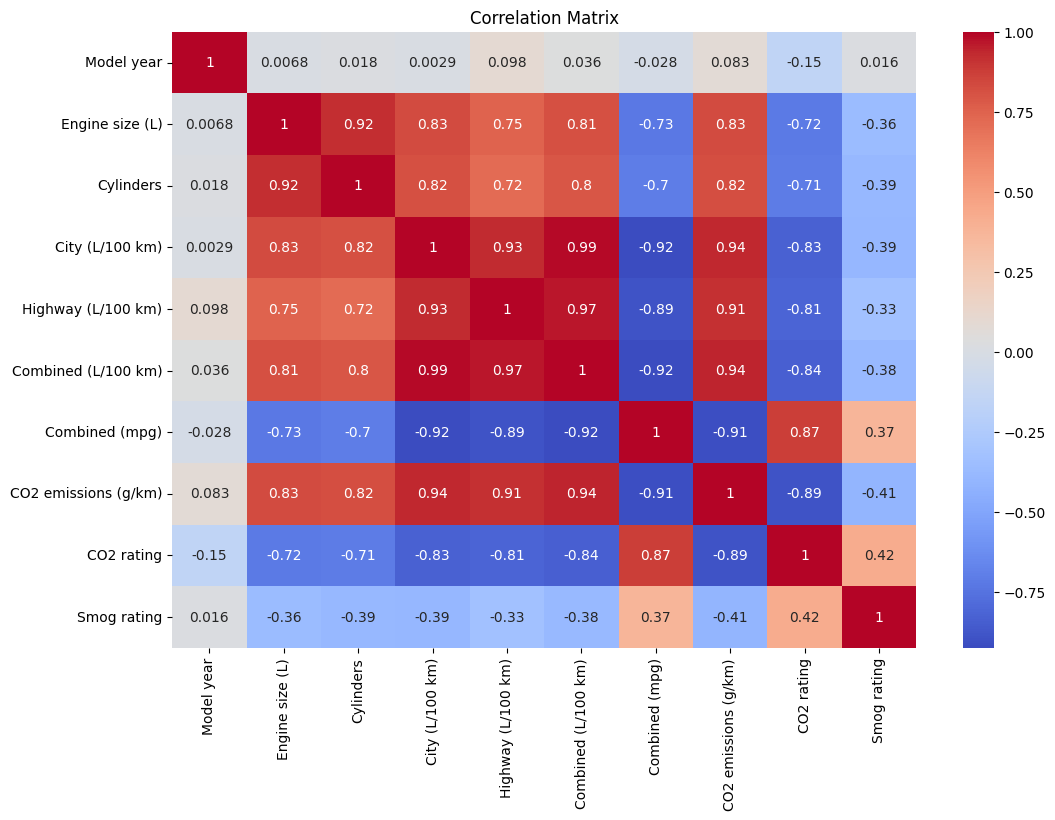

In [99]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

The correlation analysis identifies strong relationships between engine size, cylinders, fuel consumption, and CO₂ emissions, indicating that these variables are important factors influencing vehicle emissions.

**C. Trend and Comparative Analysis**

**1. CO2 emission over years**

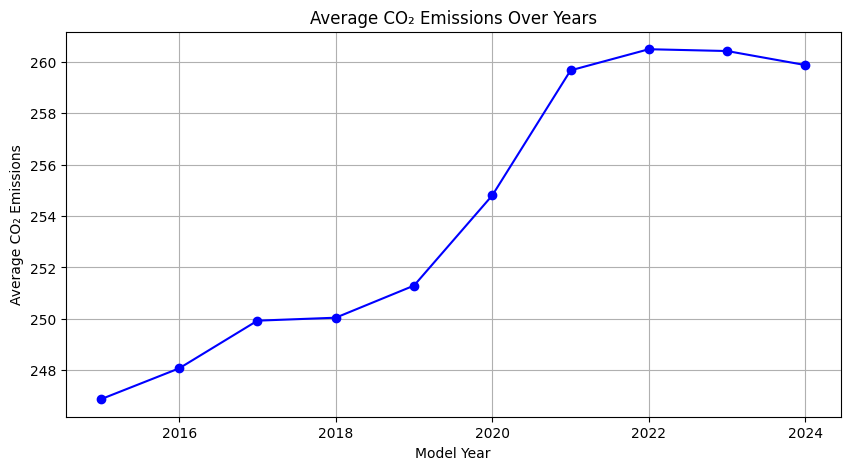

In [100]:
# CO2 emission over years
yearly_emissions = df.groupby('Model year')['CO2 emissions (g/km)'].mean()

plt.figure(figsize=(10,5))

yearly_emissions.plot(
    marker='o',
    color='blue'
)

plt.title('Average CO₂ Emissions Over Years')
plt.xlabel('Model Year')
plt.ylabel('Average CO₂ Emissions')

plt.grid(True)

plt.show()

The yearly trend analysis helps identify how average vehicle emissions have changed over time and provides insights into long-term sustainability patterns

**2. Fuel Consumption Over Years**

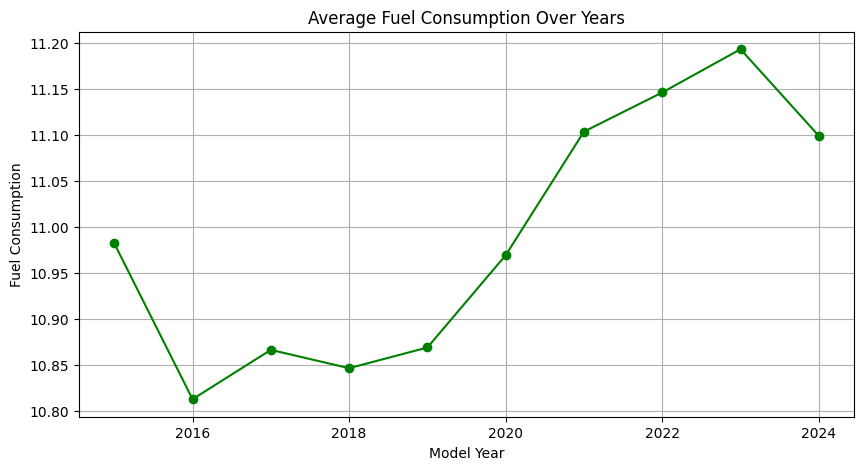

In [101]:
#  Fuel Consumption Over Years
yearly_fuel = df.groupby('Model year')['Combined (L/100 km)'].mean()

plt.figure(figsize=(10,5))

yearly_fuel.plot(
    marker='o',
    color='green'
)

plt.title('Average Fuel Consumption Over Years')
plt.xlabel('Model Year')
plt.ylabel('Fuel Consumption')

plt.grid(True)

plt.show()

The analysis shows changes in average fuel consumption across model years and helps evaluate overall fuel efficiency trends over time.



**3. Vehicle classes produce highest emissions.**

In [102]:
df.groupby('Vehicle class')['CO2 emissions (g/km)'].mean().sort_values(ascending=False)

,CO2 emissions (g/km)
Vehicle class,
Van: Passenger,389.733333
Sport utility vehicle: Standard,303.907392
Pickup truck: Standard,302.724374
Two-seater,290.161189
Pickup truck: Small,278.222727
Full-size,261.159178
Station wagon: Mid-size,259.243902
Minivan,252.557895
Minicompact,252.271739


**4. Average fuel consumption across different fuel types.**

X = Regular Gasoline,Z = Premium Gasoline,D = Diesel,E = Ethanol, N = Natural Gas

In [103]:
df.groupby('Fuel type')['Combined (L/100 km)'].mean()

,Combined (L/100 km)
Fuel type,
D,9.344492
E,16.629878
N,12.700000
X,10.056812
Z,11.595843


In [104]:
df.to_csv('cleaned_vehicle_emissions.csv', index=False)

In [105]:
!jupyter nbconvert --to html --template classic Final_EDA_820.ipynb

[NbConvertApp] Converting notebook Final_EDA_820.ipynb to html
[NbConvertApp] Writing 346147 bytes to Final_EDA_820.html


In [106]:
import os

notebook_filename = 'Final_EDA_820.ipynb'
output_html_filename = 'Final_EDA_820_with_outputs.html'

# Run the notebook and convert it to HTML, including outputs
!jupyter nbconvert --to html --execute "{notebook_filename}" --output "{output_html_filename}" --template classic

print(f"Notebook '{notebook_filename}' converted to '{output_html_filename}' with outputs.")
print(f"You can find the generated HTML file at: {os.getcwd()}/{output_html_filename}")

[NbConvertApp] Converting notebook Final_EDA_820.ipynb to html
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] WARNING | Alternative text is missing on 14 image(s).
[NbConvertApp] Writing 9440334 bytes to Final_EDA_820_with_outputs.html
Notebook '